# PIGS: Physics-Inspired Gaussian Splats

Compression of one 5D gyrokinetic snapshot into a fixed Gaussian budget. The method **ladder** (each rung
adds one verified ingredient):

| rung | call | what it adds |
|---|---|---|
| **base** | `compress_base` | VANILLA Gaussian splatting: joint AdamW MSE on minibatches — no warm-start, no separable trick. The slow reference we started from. |
| **fast** | `compress_fast` | amp warm-start (amplitudes are linear → closed-form LS) + separable warmup (Huber) + fused polish. Density only. |
| **gPINC** | `compress_gpinc` | fast + physics fine-tune (df/φ/spectra losses) on the **separable** reconstruction (~10× faster than dense, bit-identical losses). Recommended reconstruction model. |
| **PINC** | `compress_pinc` | fast + the SAME physics fine-tune but **dense** — same quality, kept only as the speed reference for gPINC. |
| **PIGS** | `compress_pigs` | gPINC + flux graft + frozen-base flux refine (POST). Production graft = **tied carrier groups**: stratified-coverage envelopes each carrying K=9 carriers at the tail k_y with shared μ/Σ (~3.7× carriers/byte; measured ~20× better flux than free carriers). Budget-neutral: `n_total = n_base + n_flux` atom-equivalents. |

All models are returned **fp16-rounded** (on-disk-fair eval) with timing in `info`.
- **§1 Quick start** — run the ladder, results table, diagnostic plots.
- **§2 Under the hood + ablations** — stage rationale; CR sweep (how far can compression go), warmup steps,
  gPINC-vs-PINC speed, flux_lambda Pareto, flux_frac budget split.

## §1 — Setup & data

In [1]:
%load_ext autoreload
%autoreload 2
import os, sys
sys.path.append("..")
os.environ["CUDA_VISIBLE_DEVICES"] = "0"
device = "cuda"

In [2]:
%matplotlib inline
import torch, numpy as np, pandas as pd, matplotlib.pyplot as plt
import neugk.pinc.pigs as pigs
from neugk.pinc.neural_fields import CycloneNFDataset

DATA_PATH = "/projects/u6eb/gyrokinetics/preprocessed_kvikio"
def load(traj="iteration_13", t=100):
    d = CycloneNFDataset(traj, timesteps=t, path=DATA_PATH, backend="kvikio",
                         realpotens=True, normalize="zscore", normalize_coords=True)
    d.to(torch.device(device)); return d
data = load()
print("snapshot bytes:", data.full_df.nbytes, " grid:", tuple(data.df.shape))

/projects/u6eb/miniconda3/envs/diffpl/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


snapshot bytes: 89128960  grid: (2, 32, 8, 16, 85, 32)


## Run the ladder
`n=1000` atoms ≈ CR 2786× at fp16 (`pigs.n_for_cr(data, cr)` inverts a target CR to N). `seed=0` makes runs
reproducible (it also resets the loader's in-place shuffle hysteresis).

In [3]:
n_total = 1000

m_base,  info_base  = pigs.compress_base (data, n_total, device, seed=0)   # vanilla (slow reference)
m_fast,  info_fast  = pigs.compress_fast (data, n_total, device, seed=0)   # fast density
m_gpinc, info_gpinc = pigs.compress_gpinc(data, n_total, device, seed=0)   # fast + gPINC (recommended)
m_pinc,  info_pinc  = pigs.compress_pinc (data, n_total, device, seed=0)   # fast + dense PINC (speed ref, ~10 min)
m_pigs,  info_pigs  = pigs.compress_pigs (data, n_total=n_total, flux_lambda=3.0, device=device, seed=0)

[1/1] vanilla density  N=1000  (73s)
done: {'n': 1000, 'quant': 'fp16', 'bytes': 32000, 'CR': 2785.3, 'time_s': 72.8}
[1/1] fast density  N=1000  (26s)
done: {'n': 1000, 'quant': 'fp16', 'bytes': 32000, 'CR': 2785.3, 'time_s': 25.8}
[1/2] fast density  N=1000  (22s)
[2/2] gPINC (separable)  (23s)
done: {'n': 1000, 'quant': 'fp16', 'bytes': 32000, 'CR': 2785.3, 'time_s': 23.4}
[1/2] fast density  N=1000  (22s)
[2/2] PINC (dense)  (576s)
done: {'n': 1000, 'quant': 'fp16', 'bytes': 32000, 'CR': 2785.3, 'time_s': 576.2}
[1/4] fast density  N_base=750  (18s)
[2/4] gPINC  (19s)
[3/4] graft  +936 TIED carriers (104 envelopes x 9)  (19s)
[4/4] POST raw  (29s)
done: {'n': 1000, 'quant': 'fp16', 'bytes': 32528, 'CR': 2740.1, 'time_s': 28.8, 'n_base': 750, 'n_flux': 936, 'tied': True, 'm_env': 104, 'tied_k': 9, 'placement': 'stratified', 'flux_mode': 'raw', 'flux_lambda': 3.0}


## Results table — the ladder at one glance
**Metric note — `flux_relL1`**: relative L1 of the **k_y-resolved heat-flux spectrum** `Q(k_y)` (the eflux
field integrated over velocity space and (s,x), per binormal mode, band k_y 1–15). It is NOT the eflux-field
error and NOT the single scalar total heat flux (the scalar sign-cancels and is degenerate — it can stay ~1
while the spectrum is perfect, and vice versa). `flux_dom` = band 1–6, `flux_tail` = band 7–15. **`eflux_int_rel`** = relative error of the
INTEGRATED scalar heat flux Q_tot=Σ_ky Q(ky) — the physical flux value (signed; can cancel, so read it
together with `flux_relL1`, not instead of it).
PSNR higher = better; flux_* lower = better.

In [4]:
results = {
    "base (vanilla GS)":   {**info_base,  **pigs.evaluate(m_base,  data, device)},
    "fast (density)":      {**info_fast,  **pigs.evaluate(m_fast,  data, device)},
    "gPINC (separable)":   {**info_gpinc, **pigs.evaluate(m_gpinc, data, device)},
    "PINC (dense, ref)":   {**info_pinc,  **pigs.evaluate(m_pinc,  data, device)},
    "PIGS (full)":         {**info_pigs,  **pigs.evaluate(m_pigs,  data, device)},
}
df = pd.DataFrame(results).T
cols = ["CR", "time_s", "PSNR(f)", "PSNR(phi)", "kyspec L1", "qspec L1", "flux_dom", "flux_tail", "flux_relL1", "eflux_int_rel"]
df[[c for c in cols if c in df.columns]]

,CR,time_s,PSNR(f),PSNR(phi),kyspec L1,qspec L1,flux_dom,flux_tail,flux_relL1,eflux_int_rel
base (vanilla GS),2785.3,72.8,32.111338,-4.990985,4.772976,1.231126,0.9902,1.0024,0.9942,0.9961
fast (density),2785.3,25.8,35.822386,-3.872418,3.686559,0.668312,0.3323,0.9124,0.5238,0.5366
gPINC (separable),2785.3,23.4,34.785633,16.631713,0.058783,0.686511,0.4001,0.8245,0.5402,0.0932
"PINC (dense, ref)",2785.3,576.2,34.78595,16.632631,0.058617,0.686518,0.4001,0.8245,0.5402,0.0932
PIGS (full),2740.1,28.8,34.280011,14.676655,0.073627,0.048731,0.0036,0.0059,0.0043,0.0348


Expected reads: **base→fast** = +PSNR(f) at a fraction of the time (warm-start + separable);
**fast→gPINC** = φ goes from ~−4 to ~+18 (physics losses); **gPINC vs PINC** = same quality, ~10× time gap;
**gPINC→PIGS** = flux_relL1 drops several× (the graft + POST), small φ/f cost.

## Visualizations — GT vs reconstruction

In [5]:
with torch.no_grad():
    f_base  = pigs.reconstruct(m_base,  data, device)
    f_gpinc = pigs.reconstruct(m_gpinc, data, device)
    f_pigs  = pigs.reconstruct(m_pigs,  data, device)
gt = data.full_df.to(device)

df nmse: 0.30, df psnr: 38.32
pflux: -0.00, eflux: 38.17, gt eflux 39.55
phi nmse: 0.76, phi psnr: -3.33
kyspec L1: 6.10, kyspec mono: 0.06
qspec L1: 0.05, qspec mono: 0.01



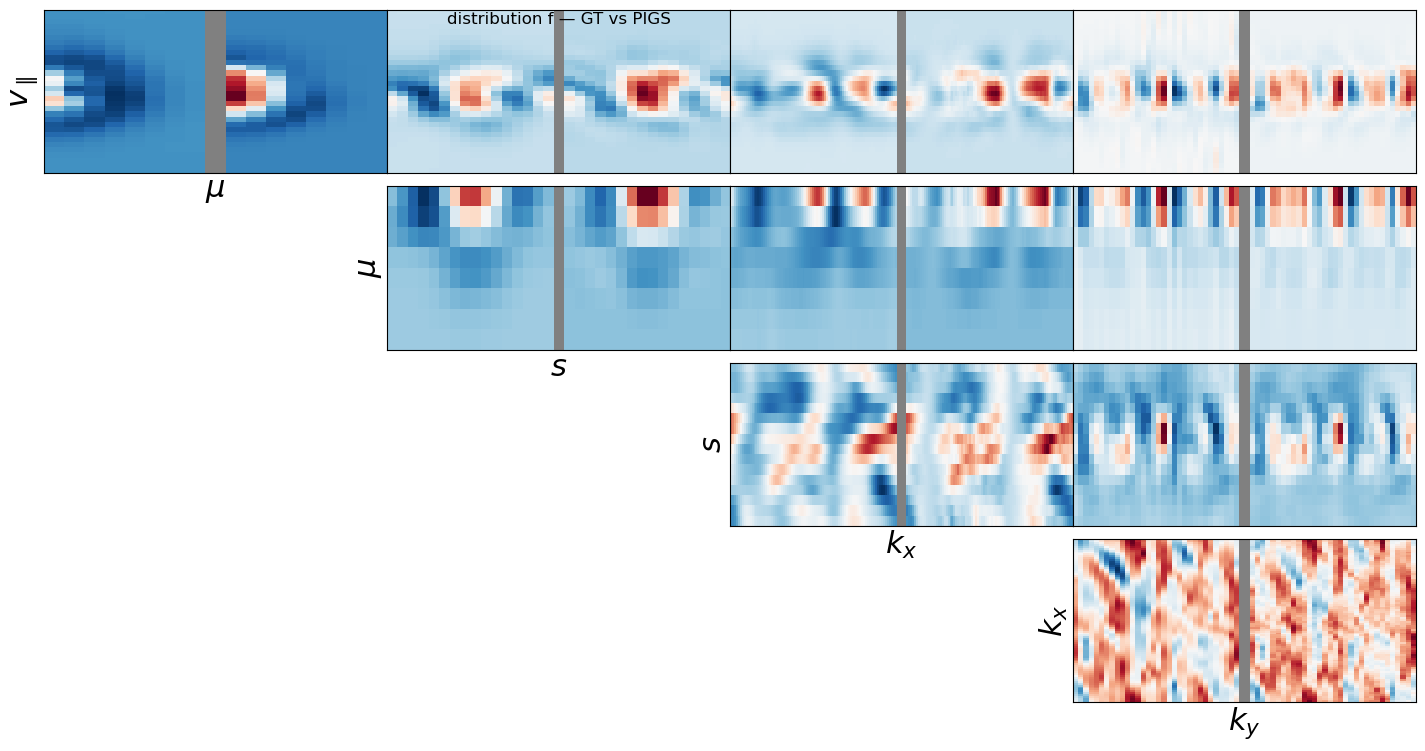

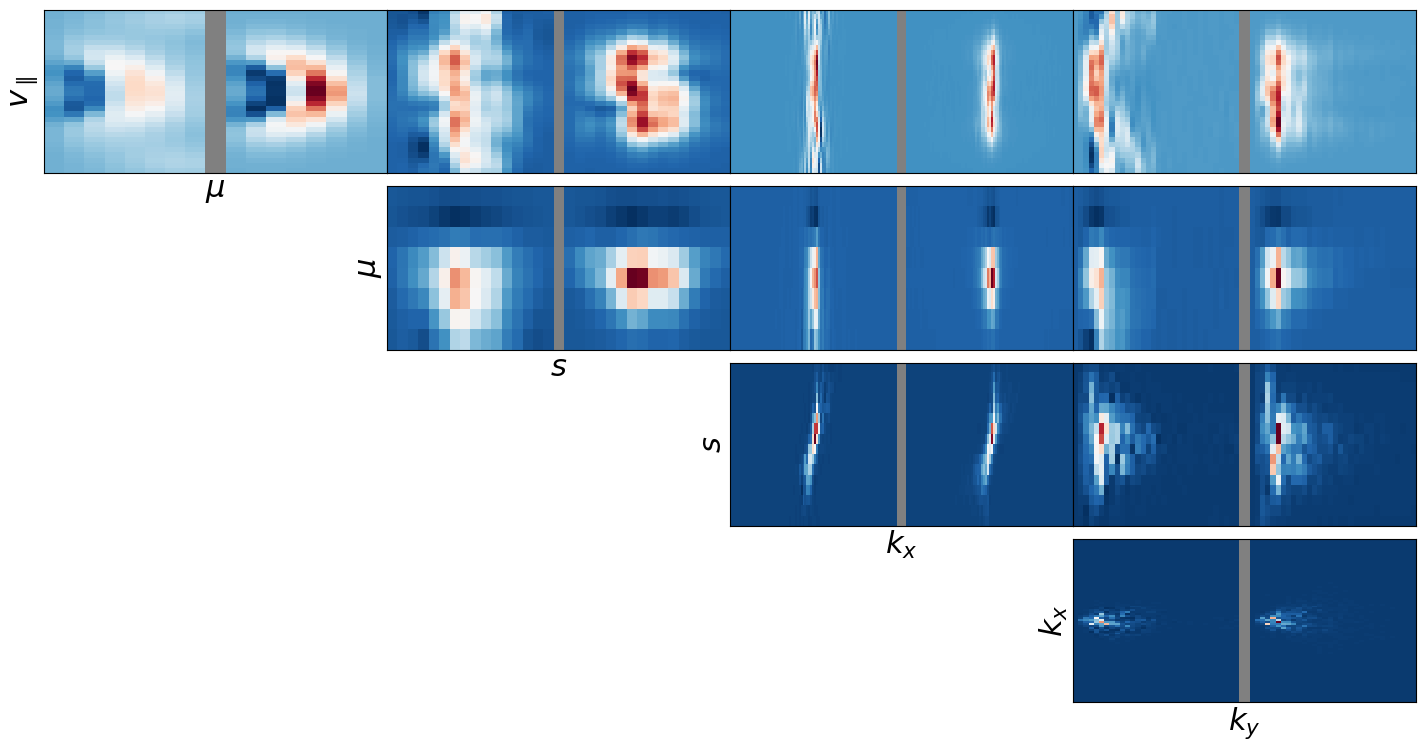

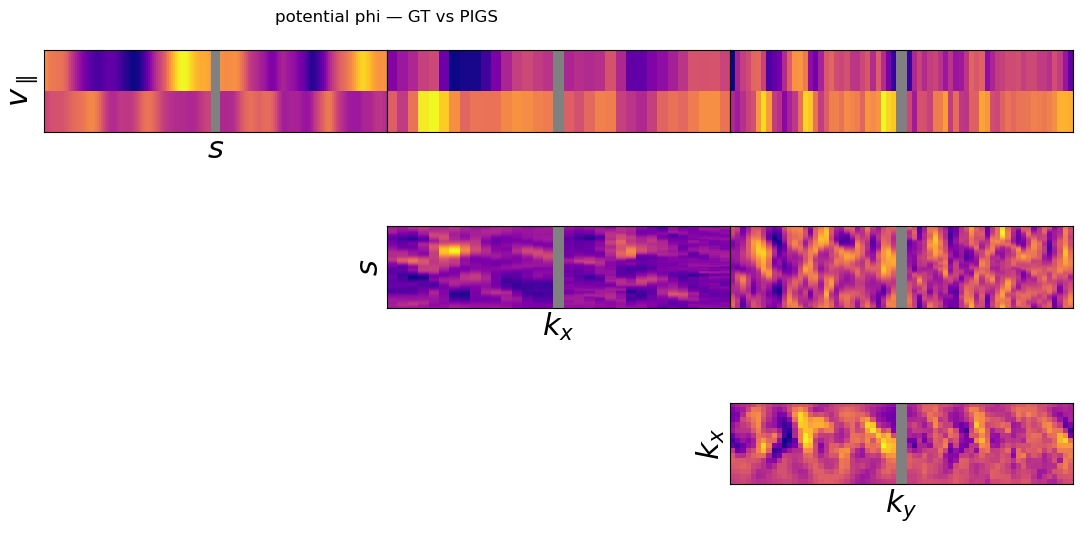

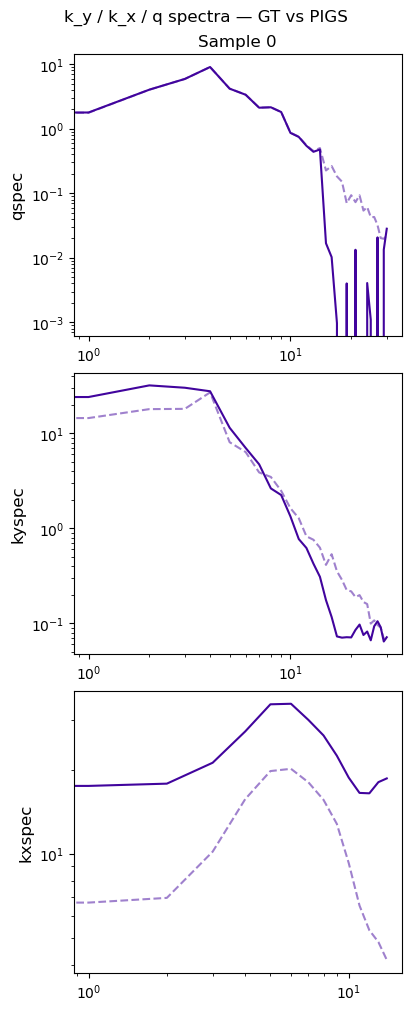

In [6]:
from neugk.pinc.neural_fields.nf_train import eval_diagnose
fig_df, fig_eflux, fig_potens, fig_diag = eval_diagnose(data, torch.device(device), pred_df=f_pigs)
fig_df.suptitle("distribution f — GT vs PIGS")
fig_potens.suptitle("potential phi — GT vs PIGS")
fig_diag.suptitle("k_y / k_x / q spectra — GT vs PIGS")
plt.show()

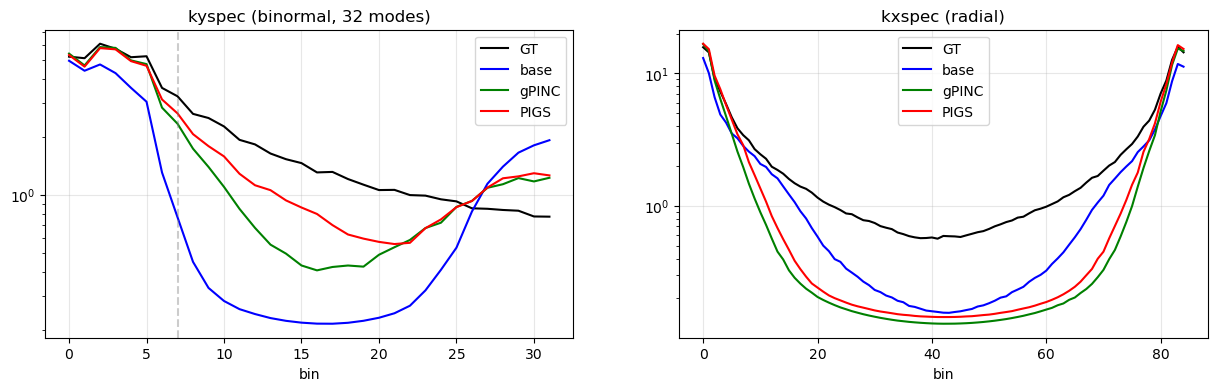

In [7]:
# Spectral comparison across rungs. df is COMPLEX (the 2 channels are Re/Im), so the spectrum is the
# full complex FFT -> all 32 distinct ky modes (an rfft of the real channels would only show 17).
from neugk.pinc.neural_fields.nf_utils import to_complex
fig, axes = plt.subplots(1, 2, figsize=(15, 4))
methods = [("GT", gt), ("base", f_base), ("gPINC", f_gpinc), ("PIGS", f_pigs)]
colors = ["black", "blue", "green", "red"]
for ax, dim, mean_dims, name in [(axes[0], -1, (0, 1, 2, 3), "kyspec (binormal, 32 modes)"),
                                 (axes[1], -2, (0, 1, 2, 4), "kxspec (radial)")]:
    for (mn, field), c in zip(methods, colors):
        spec = torch.fft.fft(to_complex(field), dim=dim).abs().mean(dim=mean_dims).cpu().numpy()
        ax.semilogy(np.arange(len(spec)), spec + 1e-8, label=mn, color=c, lw=1.5)
    ax.set_title(name); ax.set_xlabel("bin"); ax.grid(alpha=0.3); ax.legend()
axes[0].axvline(7, color="gray", ls="--", alpha=0.4)
plt.show()

## §2 — Under the hood

### What each stage does (and why it works)
- **base** (`train_default`): importance-sampled init + joint AdamW MSE on shuffled voxel batches. Slow
  because every step touches a 200k-voxel batch through the dense forward; no structure exploited.
- **fast** (`train_fast`): (i) the field is **linear in the amplitudes** → closed-form least-squares
  warm-start; (ii) **block-diagonal Σ** → each Gaussian factorizes over (velocity × space) → one exact
  full-grid step is a GEMM (~17 ms vs ~6 s dense); (iii) short fused polish. **Huber** loss preserves the
  subdominant modes that energy-greedy MSE starves.
- **gPINC / PINC** (`train_pinc`): physics multi-loss (df, flux, φ, kyspec, qspec, monotonicity).
  `mode='gpinc'` evaluates it on the separable reconstruction — **bit-identical losses, ~10× faster**;
  `mode='dense'` is the same thing through the dense forward (the speed reference).
- **PIGS graft + POST** (`tied_centers` + `add_atoms` + `refine_flux`): the heat flux `Q(ky)=Im(df_k·conj(φ_k))`
  lives at tail ky the plain Gaussians can't reach (a real Gaussian's y-spectrum sits at ky=0; one Gabor
  carrier = one independent per-bin cross-phase DOF). Production graft = **tied carrier groups**: envelopes
  placed for **coverage** (stratified over the grid — measured ~6× better flux and +4–6 dB φ than residual
  hotspots), each carrying K=9 carriers at the tail bins with **shared μ/Σ** (14+3K params vs 17K → ~3.7×
  carriers per byte → ~20× better flux at the same bytes). Complex amps warm-started in closed form; then
  **freeze the φ-optimal base** and POST-refine the carrier amps only (tying + on-bin ky stay exact):
  `raw` (match Q, min total flux) or `wnorm` (match W=Q/|φ|², φ-preserving tail-only); `flux_lambda` slides
  the Pareto. `tied=False` gives the older free-carrier graft.

## Ablations

### A1 — How far can compression go? (CR sweep)
Quality vs compression ratio for the recommended model (`compress_gpinc`). Low CR = many Gaussians (slow,
heavy): for N > 6000 we skip the fused polish (`polish_epochs=0`) to avoid the (B,N) memory blow-up.

In [8]:
CRS = [4000, 2000, 1000, 500, 250]     # 100x is heavy (~28k atoms) -- drop it for a quick look
cr_rows = []
for cr in CRS:
    n = pigs.n_for_cr(data, cr)
    kw = dict(polish_epochs=0) if n > 6000 else {}
    m, info = pigs.compress_gpinc(data, n, device, seed=0, verbose=False, **kw)
    e = pigs.evaluate(m, data, device)
    cr_rows.append({"target_CR": cr, "n": n, "CR": info["CR"], "t_s": info["time_s"],
                    **{k: round(v, 3) for k, v in e.items()}})
    print(f"CR={cr:5d} n={n:6d} t={info['time_s']:6.1f}s f={e['PSNR(f)']:.2f} phi={e['PSNR(phi)']:.2f} "
          f"flux={e['flux_relL1']:.3f}")
df_cr = pd.DataFrame(cr_rows); df_cr

CR= 4000 n=   696 t=  17.9s f=34.28 phi=18.36 flux=0.546
CR= 2000 n=  1392 t=  31.1s f=35.31 phi=18.91 flux=0.570
CR= 1000 n=  2785 t=  60.7s f=37.00 phi=21.22 flux=0.398
CR=  500 n=  5570 t= 115.9s f=37.24 phi=20.87 flux=0.382
CR=  250 n= 11141 t= 145.2s f=37.02 phi=19.74 flux=0.295


,target_CR,n,CR,t_s,PSNR(f),PSNR(phi),kyspec L1,qspec L1,flux_dom,flux_tail,flux_relL1,eflux_int_rel
0,4000,696,4001.8,17.9,34.284,18.365,0.025,0.693,0.359,0.925,0.546,0.333
1,2000,1392,2000.9,31.1,35.313,18.914,0.032,0.722,0.482,0.749,0.570,0.010
2,1000,2785,1000.1,60.7,37.003,21.216,0.025,0.516,0.326,0.543,0.398,0.004
3,500,5570,500.1,115.9,37.241,20.865,0.023,0.499,0.327,0.493,0.382,0.021
4,250,11141,250.0,145.2,37.023,19.738,0.021,0.394,0.239,0.410,0.295,0.002


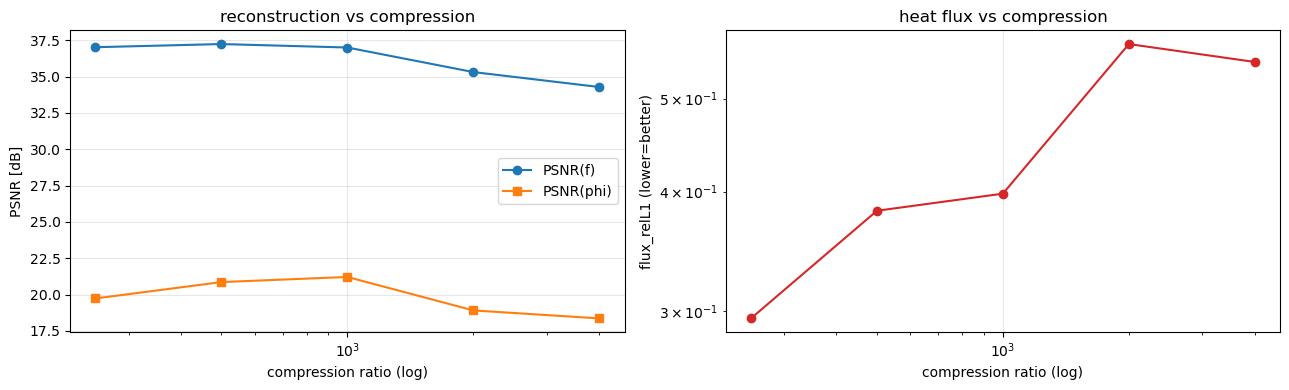

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].semilogx(df_cr["CR"], df_cr["PSNR(f)"], "-o", label="PSNR(f)")
ax[0].semilogx(df_cr["CR"], df_cr["PSNR(phi)"], "-s", label="PSNR(phi)")
ax[0].set_xlabel("compression ratio (log)"); ax[0].set_ylabel("PSNR [dB]"); ax[0].legend(); ax[0].grid(alpha=0.3)
ax[0].set_title("reconstruction vs compression")
ax[1].loglog(df_cr["CR"], df_cr["flux_relL1"], "-o", color="tab:red")
ax[1].set_xlabel("compression ratio (log)"); ax[1].set_ylabel("flux_relL1 (lower=better)"); ax[1].grid(alpha=0.3)
ax[1].set_title("heat flux vs compression")
plt.tight_layout(); plt.show()

### A2 — Density warmup steps (real sweep via kwargs passthrough)
`compress_fast(..., warmup_steps=s)` forwards to `train_fast`. The curve flattens ~step 500–600.

In [10]:
abl = []
for s in [100, 250, 500, 1000, 2000]:
    m, info = pigs.compress_fast(data, n_total, device, warmup_steps=s, seed=0, verbose=False)
    e = pigs.evaluate(m, data, device)
    abl.append({"warmup_steps": s, "t_s": info["time_s"], "PSNR(f)": round(e["PSNR(f)"], 2)})
    print(f"steps={s:5d}: t={info['time_s']:5.1f}s f={e['PSNR(f)']:.2f}dB")
pd.DataFrame(abl)

steps=  100: t=  9.2s f=32.33dB
steps=  250: t= 11.4s f=33.74dB
steps=  500: t= 14.9s f=34.94dB
steps= 1000: t= 22.0s f=35.82dB
steps= 2000: t= 36.2s f=36.31dB


,warmup_steps,t_s,PSNR(f)
0,100,9.2,32.33
1,250,11.4,33.74
2,500,14.9,34.94
3,1000,22.0,35.82
4,2000,36.2,36.31


### A3 — gPINC vs dense PINC (the speed reference)
Same physics losses, same epochs — only the reconstruction path differs (already run in §1):

In [11]:
pd.DataFrame({
    "gPINC (separable)": {"time_s": info_gpinc["time_s"], **{k: round(v,3) for k,v in pigs.evaluate(m_gpinc, data, device).items()}},
    "PINC (dense)":      {"time_s": info_pinc["time_s"],  **{k: round(v,3) for k,v in pigs.evaluate(m_pinc, data, device).items()}},
}).T

,time_s,PSNR(f),PSNR(phi),kyspec L1,qspec L1,flux_dom,flux_tail,flux_relL1,eflux_int_rel
gPINC (separable),23.4,34.786,16.632,0.059,0.687,0.4,0.825,0.54,0.093
PINC (dense),576.2,34.786,16.633,0.059,0.687,0.4,0.825,0.54,0.093


### A4 — PIGS flux_lambda Pareto (raw vs wnorm)
Sweep the POST knob on the PRODUCTION (tied) recipe. `seed=0` makes the rows share identical base/graft
randomness, so the differences are purely the objective.

In [12]:
rows = []
for mode, lams in [("raw", [1.0, 3.0, 10.0]), ("wnorm", [1.0, 3.0])]:
    for L in lams:
        m, info = pigs.compress_pigs(data, n_total=n_total, flux_mode=mode, flux_lambda=L,
                                     device=device, seed=0, verbose=False)
        e = pigs.evaluate(m, data, device)
        rows.append({"mode": mode, "lambda": L, "t_s": info["time_s"],
                     "PSNR(phi)": round(e["PSNR(phi)"], 2), "flux_tail": e["flux_tail"], "flux_all": e["flux_relL1"]})
        print(rows[-1])
dfp = pd.DataFrame(rows); dfp

{'mode': 'raw', 'lambda': 1.0, 't_s': 27.9, 'PSNR(phi)': 15.12, 'flux_tail': 0.0147, 'flux_all': 0.0088}
{'mode': 'raw', 'lambda': 3.0, 't_s': 27.9, 'PSNR(phi)': 14.68, 'flux_tail': 0.0059, 'flux_all': 0.0043}
{'mode': 'raw', 'lambda': 10.0, 't_s': 27.9, 'PSNR(phi)': 14.35, 'flux_tail': 0.0026, 'flux_all': 0.0023}
{'mode': 'wnorm', 'lambda': 1.0, 't_s': 28.1, 'PSNR(phi)': 16.39, 'flux_tail': 0.1602, 'flux_all': 0.2941}
{'mode': 'wnorm', 'lambda': 3.0, 't_s': 28.0, 'PSNR(phi)': 15.98, 'flux_tail': 0.1452, 'flux_all': 0.2909}


,mode,lambda,t_s,PSNR(phi),flux_tail,flux_all
0,raw,1.0,27.9,15.12,0.0147,0.0088
1,raw,3.0,27.9,14.68,0.0059,0.0043
2,raw,10.0,27.9,14.35,0.0026,0.0023
3,wnorm,1.0,28.1,16.39,0.1602,0.2941
4,wnorm,3.0,28.0,15.98,0.1452,0.2909


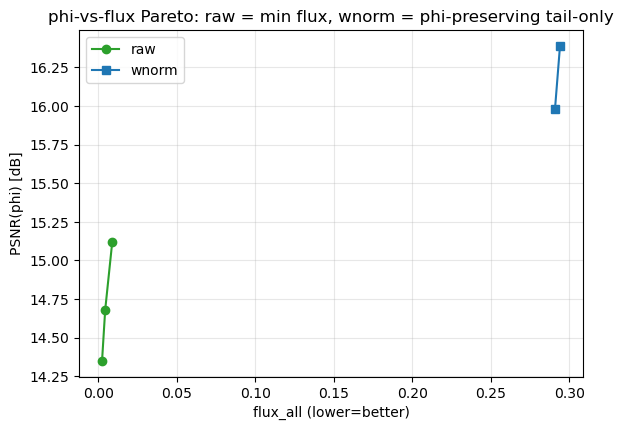

In [13]:
fig, ax = plt.subplots(figsize=(6.5, 4.5))
for mode, mk, c in [("raw", "o", "tab:green"), ("wnorm", "s", "tab:blue")]:
    s = dfp[dfp["mode"] == mode]; ax.plot(s["flux_all"], s["PSNR(phi)"], "-" + mk, c=c, label=mode)
ax.set_xlabel("flux_all (lower=better)"); ax.set_ylabel("PSNR(phi) [dB]")
ax.set_title("phi-vs-flux Pareto: raw = min flux, wnorm = phi-preserving tail-only")
ax.legend(); ax.grid(alpha=0.3); plt.show()

### A5 — Budget split (flux_frac): how many atoms to reserve for flux?

In [14]:
frac_rows = []
for frac in [0.1, 0.25, 0.5]:
    m, info = pigs.compress_pigs(data, n_total=n_total, flux_frac=frac, device=device, seed=0, verbose=False)
    e = pigs.evaluate(m, data, device)
    frac_rows.append({"flux_frac": frac, "n_base": info["n_base"], "n_flux": info["n_flux"],
                      "t_s": info["time_s"], "PSNR(f)": round(e["PSNR(f)"], 2),
                      "PSNR(phi)": round(e["PSNR(phi)"], 2), "flux_relL1": round(e["flux_relL1"], 4)})
    print(frac_rows[-1])
pd.DataFrame(frac_rows)

{'flux_frac': 0.1, 'n_base': 900, 'n_flux': 369, 't_s': 29.7, 'PSNR(f)': 34.32, 'PSNR(phi)': 14.92, 'flux_relL1': 0.0155}
{'flux_frac': 0.25, 'n_base': 750, 'n_flux': 936, 't_s': 27.8, 'PSNR(f)': 34.28, 'PSNR(phi)': 14.68, 'flux_relL1': 0.0043}
{'flux_frac': 0.5, 'n_base': 500, 'n_flux': 1863, 't_s': 25.6, 'PSNR(f)': 33.8, 'PSNR(phi)': 14.93, 'flux_relL1': 0.0037}


,flux_frac,n_base,n_flux,t_s,PSNR(f),PSNR(phi),flux_relL1
0,0.10,900,369,29.7,34.32,14.92,0.0155
1,0.25,750,936,27.8,34.28,14.68,0.0043
2,0.50,500,1863,25.6,33.80,14.93,0.0037


## Notes
- **Self-contained**: `neugk.pinc.pigs` depends only on the shared `neugk` data loader + physics losses
  (no prior gsplat iterations).
- **PIGS = density → gPINC → flux graft → POST refine** (no hand-in-hand stage — measured: the dedicated
  frozen-base refine is what delivers the flux; see `gsplat_speed/RESULTS.md` for the full study).
- **gPINC speed**: the separable reconstruction is bit-identical through the FFT physics losses, ~10× faster.
- **Budget-neutral flux**: at fixed `n_total`, the flux atoms replace Gaussians (file size unchanged;
  each Gabor atom stores 17 params vs 16 — the +1 is its carrier ky).
- **fp16**: all returned models are fp16-rounded (verified ~lossless, even for the flux cross-phase), so
  `evaluate()` reflects what is on disk.